In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from numpy import loadtxt
from keras.layers import Dense
from keras.models import Sequential

In [6]:
df= pd.read_csv(r'C:\Users\SHYAM SASHANK\OneDrive\Desktop\Data_Science\Assginment_CSV\forestfires.csv')
df

,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,...,monthfeb,monthjan,monthjul,monthjun,monthmar,monthmay,monthnov,monthoct,monthsep,size_category
0,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,...,0,0,0,0,1,0,0,0,0,small
1,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,...,0,0,0,0,0,0,0,1,0,small
2,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,...,0,0,0,0,0,0,0,1,0,small
3,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,...,0,0,0,0,1,0,0,0,0,small
4,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,...,0,0,0,0,1,0,0,0,0,small
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
512,aug,sun,81.6,56.7,665.6,1.9,27.8,32,2.7,0.0,...,0,0,0,0,0,0,0,0,0,large
513,aug,sun,81.6,56.7,665.6,1.9,21.9,71,5.8,0.0,...,0,0,0,0,0,0,0,0,0,large
514,aug,sun,81.6,56.7,665.6,1.9,21.2,70,6.7,0.0,...,0,0,0,0,0,0,0,0,0,large
515,aug,sat,94.4,146.0,614.7,11.3,25.6,42,4.0,0.0,...,0,0,0,0,0,0,0,0,0,small


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 31 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   month          517 non-null    object 
 1   day            517 non-null    object 
 2   FFMC           517 non-null    float64
 3   DMC            517 non-null    float64
 4   DC             517 non-null    float64
 5   ISI            517 non-null    float64
 6   temp           517 non-null    float64
 7   RH             517 non-null    int64  
 8   wind           517 non-null    float64
 9   rain           517 non-null    float64
 10  area           517 non-null    float64
 11  dayfri         517 non-null    int64  
 12  daymon         517 non-null    int64  
 13  daysat         517 non-null    int64  
 14  daysun         517 non-null    int64  
 15  daythu         517 non-null    int64  
 16  daytue         517 non-null    int64  
 17  daywed         517 non-null    int64  
 18  monthapr  

In [4]:
df.describe()

,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area,dayfri,...,monthdec,monthfeb,monthjan,monthjul,monthjun,monthmar,monthmay,monthnov,monthoct,monthsep
count,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,...,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000
mean,90.644681,110.872340,547.940039,9.021663,18.889168,44.288201,4.017602,0.021663,12.847292,0.164410,...,0.017408,0.038685,0.003868,0.061896,0.032882,0.104449,0.003868,0.001934,0.029014,0.332689
std,5.520111,64.046482,248.066192,4.559477,5.806625,16.317469,1.791653,0.295959,63.655818,0.371006,...,0.130913,0.193029,0.062137,0.241199,0.178500,0.306138,0.062137,0.043980,0.168007,0.471632
min,18.700000,1.100000,7.900000,0.000000,2.200000,15.000000,0.400000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,90.200000,68.600000,437.700000,6.500000,15.500000,33.000000,2.700000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,91.600000,108.300000,664.200000,8.400000,19.300000,42.000000,4.000000,0.000000,0.520000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,92.900000,142.400000,713.900000,10.800000,22.800000,53.000000,4.900000,0.000000,6.570000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,96.200000,291.300000,860.600000,56.100000,33.300000,100.000000,9.400000,6.400000,1090.840000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [5]:
df.corr()

,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area,dayfri,...,monthdec,monthfeb,monthjan,monthjul,monthjun,monthmar,monthmay,monthnov,monthoct,monthsep
FFMC,1.000000,0.382619,0.330512,0.531805,0.431532,-0.300995,-0.028485,0.056702,0.040122,0.019306,...,-0.137044,-0.281535,-0.454771,0.031833,-0.040634,-0.074327,-0.037230,-0.088964,-0.005998,0.076609
DMC,0.382619,1.000000,0.682192,0.305128,0.469594,0.073795,-0.105342,0.074790,0.072994,-0.012010,...,-0.176301,-0.317899,-0.105647,-0.001946,-0.050403,-0.407404,-0.081980,-0.074218,-0.187632,0.110907
DC,0.330512,0.682192,1.000000,0.229154,0.496208,-0.039192,-0.203466,0.035861,0.049383,-0.004220,...,-0.105642,-0.399277,-0.115064,-0.100887,-0.186183,-0.650427,-0.114209,-0.078380,0.093279,0.531857
ISI,0.531805,0.305128,0.229154,1.000000,0.394287,-0.132517,0.106826,0.067668,0.008258,0.046695,...,-0.162322,-0.249777,-0.103588,0.020982,0.111516,-0.143520,-0.060493,-0.076559,-0.071154,-0.068877
temp,0.431532,0.469594,0.496208,0.394287,1.000000,-0.527390,-0.227116,0.069491,0.097844,-0.071949,...,-0.329648,-0.320015,-0.146520,0.142588,0.051015,-0.341797,-0.045540,-0.053798,-0.053513,0.088006
RH,-0.300995,0.073795,-0.039192,-0.132517,-0.527390,1.000000,0.069410,0.099751,-0.075519,0.064506,...,-0.047714,0.140430,0.170923,0.013185,0.009382,-0.089836,0.086822,-0.035885,-0.072334,-0.062596
wind,-0.028485,-0.105342,-0.203466,0.106826,-0.227116,0.069410,1.000000,0.061119,0.012317,0.118090,...,0.269702,-0.029431,-0.070245,-0.040645,0.012124,0.181433,0.015054,0.011864,-0.053850,-0.181476
rain,0.056702,0.074790,0.035861,0.067668,0.069491,0.099751,0.061119,1.000000,-0.007366,-0.004261,...,-0.009752,-0.014698,-0.004566,-0.013390,-0.013510,-0.020744,-0.004566,-0.003225,-0.012665,-0.051733
area,0.040122,0.072994,0.049383,0.008258,0.097844,-0.075519,0.012317,-0.007366,1.000000,-0.052911,...,0.001010,-0.020732,-0.012589,0.006149,-0.020314,-0.045596,0.006264,-0.008893,-0.016878,0.056573
dayfri,0.019306,-0.012010,-0.004220,0.046695,-0.071949,0.064506,0.118090,-0.004261,-0.052911,1.000000,...,-0.019140,0.046323,-0.027643,-0.048969,0.006000,0.036205,0.056423,-0.019527,-0.045585,0.107671


In [7]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
512    False
513    False
514    False
515    False
516    False
Length: 517, dtype: bool

In [8]:
df[df.duplicated()].shape

(8, 31)

In [9]:
df[df.duplicated()]

,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,...,monthfeb,monthjan,monthjul,monthjun,monthmar,monthmay,monthnov,monthoct,monthsep,size_category
53,aug,wed,92.1,111.2,654.1,9.6,20.4,42,4.9,0.0,...,0,0,0,0,0,0,0,0,0,small
100,aug,sun,91.4,142.4,601.4,10.6,19.8,39,5.4,0.0,...,0,0,0,0,0,0,0,0,0,small
215,mar,sat,91.7,35.8,80.8,7.8,17.0,27,4.9,0.0,...,0,0,0,0,1,0,0,0,0,large
303,jun,fri,91.1,94.1,232.1,7.1,19.2,38,4.5,0.0,...,0,0,0,1,0,0,0,0,0,small
426,aug,thu,91.6,248.4,753.8,6.3,20.4,56,2.2,0.0,...,0,0,0,0,0,0,0,0,0,small
461,aug,sat,93.7,231.1,715.1,8.4,18.9,64,4.9,0.0,...,0,0,0,0,0,0,0,0,0,small
501,aug,tue,96.1,181.1,671.2,14.3,21.6,65,4.9,0.8,...,0,0,0,0,0,0,0,0,0,small
508,aug,fri,91.0,166.9,752.6,7.1,25.9,41,3.6,0.0,...,0,0,0,0,0,0,0,0,0,small


In [10]:
df1=df.drop_duplicates()
df1.shape

(509, 31)

In [11]:
df1['size_category'].value_counts()

small    371
large    138
Name: size_category, dtype: int64

In [12]:
df1['size_category'].describe()

count       509
unique        2
top       small
freq        371
Name: size_category, dtype: object

In [13]:
df1.corr()

,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area,dayfri,...,monthdec,monthfeb,monthjan,monthjul,monthjun,monthmar,monthmay,monthnov,monthoct,monthsep
FFMC,1.000000,0.382925,0.331956,0.531926,0.431744,-0.306262,-0.030409,0.052280,0.040998,0.020889,...,-0.136614,-0.281054,-0.455128,0.033137,-0.041972,-0.074706,-0.036983,-0.088879,-0.005172,0.080444
DMC,0.382925,1.000000,0.681446,0.309459,0.470875,0.062772,-0.104563,0.071017,0.076932,-0.011152,...,-0.177044,-0.319691,-0.106256,0.000617,-0.047759,-0.404974,-0.082312,-0.074642,-0.188126,0.119779
DC,0.331956,0.681446,1.000000,0.229757,0.496608,-0.047971,-0.202856,0.033772,0.051542,-0.001642,...,-0.106347,-0.402201,-0.115871,-0.101518,-0.178719,-0.648890,-0.115010,-0.078927,0.094091,0.538299
ISI,0.531926,0.309459,0.229757,1.000000,0.395858,-0.135955,0.104834,0.062132,0.008429,0.051599,...,-0.162761,-0.250494,-0.103846,0.020932,0.119765,-0.143589,-0.060655,-0.076748,-0.071401,-0.069600
temp,0.431744,0.470875,0.496608,0.395858,1.000000,-0.532503,-0.227754,0.067911,0.099173,-0.077766,...,-0.329774,-0.319901,-0.146547,0.143987,0.052779,-0.342129,-0.045372,-0.053720,-0.052918,0.091428
RH,-0.306262,0.062772,-0.047971,-0.135955,-0.532503,1.000000,0.070721,0.094343,-0.074554,0.069599,...,-0.047670,0.141593,0.171900,0.013808,0.014425,-0.083581,0.087384,-0.035967,-0.072335,-0.061631
wind,-0.030409,-0.104563,-0.202856,0.104834,-0.227754,0.070721,1.000000,0.059332,0.012623,0.121056,...,0.270919,-0.028820,-0.070217,-0.039880,0.010124,0.181610,0.015311,0.012049,-0.053404,-0.180211
rain,0.052280,0.071017,0.033772,0.062132,0.067911,0.094343,0.059332,1.000000,-0.006511,-0.001723,...,-0.009262,-0.013961,-0.004336,-0.012411,-0.012437,-0.019189,-0.004336,-0.003063,-0.012030,-0.049319
area,0.040998,0.076932,0.051542,0.008429,0.099173,-0.074554,0.012623,-0.006511,1.000000,-0.052390,...,0.000706,-0.021205,-0.012737,0.005566,-0.019083,-0.048394,0.006124,-0.008997,-0.017284,0.055191
dayfri,0.020889,-0.011152,-0.001642,0.051599,-0.077766,0.069599,0.121056,-0.001723,-0.052390,1.000000,...,-0.018868,0.047592,-0.027723,-0.048598,-0.018562,0.041050,0.057284,-0.019584,-0.045470,0.111903


<AxesSubplot:>

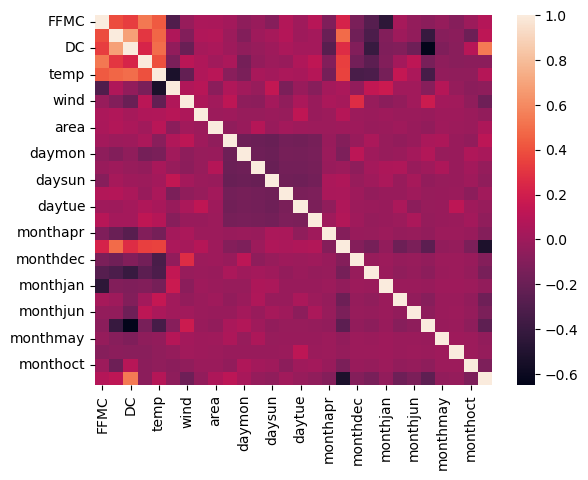

In [14]:
sns.heatmap(df1.corr())

In [15]:
df1['month']=df1['month'].astype('category')
df1['day']=df1['day'].astype('category')

In [16]:
from sklearn import preprocessing
label_encoder =preprocessing.LabelEncoder()

In [17]:
df1['month']=label_encoder.fit_transform(df1['month'])
df1['day']=label_encoder.fit_transform(df1['day'])
df1['size_category']=label_encoder.fit_transform(df1['size_category'])

In [18]:
df1

,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,...,monthfeb,monthjan,monthjul,monthjun,monthmar,monthmay,monthnov,monthoct,monthsep,size_category
0,7,0,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,...,0,0,0,0,1,0,0,0,0,1
1,10,5,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,...,0,0,0,0,0,0,0,1,0,1
2,10,2,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,...,0,0,0,0,0,0,0,1,0,1
3,7,0,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,...,0,0,0,0,1,0,0,0,0,1
4,7,3,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,...,0,0,0,0,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
512,1,3,81.6,56.7,665.6,1.9,27.8,32,2.7,0.0,...,0,0,0,0,0,0,0,0,0,0
513,1,3,81.6,56.7,665.6,1.9,21.9,71,5.8,0.0,...,0,0,0,0,0,0,0,0,0,0
514,1,3,81.6,56.7,665.6,1.9,21.2,70,6.7,0.0,...,0,0,0,0,0,0,0,0,0,0
515,1,2,94.4,146.0,614.7,11.3,25.6,42,4.0,0.0,...,0,0,0,0,0,0,0,0,0,1


In [19]:
x=df1.iloc[:,0:30]
y=df1.iloc[:,30]

In [20]:
x

,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,...,monthdec,monthfeb,monthjan,monthjul,monthjun,monthmar,monthmay,monthnov,monthoct,monthsep
0,7,0,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,...,0,0,0,0,0,1,0,0,0,0
1,10,5,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,...,0,0,0,0,0,0,0,0,1,0
2,10,2,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,...,0,0,0,0,0,0,0,0,1,0
3,7,0,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,...,0,0,0,0,0,1,0,0,0,0
4,7,3,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,...,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
512,1,3,81.6,56.7,665.6,1.9,27.8,32,2.7,0.0,...,0,0,0,0,0,0,0,0,0,0
513,1,3,81.6,56.7,665.6,1.9,21.9,71,5.8,0.0,...,0,0,0,0,0,0,0,0,0,0
514,1,3,81.6,56.7,665.6,1.9,21.2,70,6.7,0.0,...,0,0,0,0,0,0,0,0,0,0
515,1,2,94.4,146.0,614.7,11.3,25.6,42,4.0,0.0,...,0,0,0,0,0,0,0,0,0,0


In [21]:
y

0      1
1      1
2      1
3      1
4      1
      ..
512    0
513    0
514    0
515    1
516    1
Name: size_category, Length: 509, dtype: int32

In [25]:
model=Sequential()
model.add(Dense(15, input_dim=30, activation='relu'))
model.add(Dense(15, activation='relu'))
model.add(Dense(1, activation='linear'))

In [26]:
model.compile(loss='mse', optimizer='adam', metrics=['mae'])

In [27]:
model.fit(x,y, validation_split=0.33, epochs=150, batch_size=100)

Epoch 1/150
4/4 [==============================] - 1s 76ms/step - loss: 22278.9824 - mae: 136.4200 - val_loss: 24712.7656 - val_mae: 144.7652
Epoch 2/150
4/4 [==============================] - 0s 16ms/step - loss: 18973.8477 - mae: 125.5599 - val_loss: 21001.1465 - val_mae: 133.2151
Epoch 3/150
4/4 [==============================] - 0s 14ms/step - loss: 16068.6963 - mae: 115.3259 - val_loss: 17846.5039 - val_mae: 122.5578
Epoch 4/150
4/4 [==============================] - 0s 13ms/step - loss: 13683.0635 - mae: 106.1361 - val_loss: 15177.4199 - val_mae: 112.8010
Epoch 5/150
4/4 [==============================] - 0s 15ms/step - loss: 11637.5322 - mae: 97.7054 - val_loss: 12943.3008 - val_mae: 103.9880
Epoch 6/150
4/4 [==============================] - 0s 13ms/step - loss: 9990.9277 - mae: 90.2946 - val_loss: 11061.8105 - val_mae: 96.0169
Epoch 7/150
4/4 [==============================] - 0s 13ms/step - loss: 8582.8721 - mae: 83.4485 - val_loss: 9484.6865 - val_mae: 88.8800
Epoch 8/150
4/

4/4 [==============================] - 0s 13ms/step - loss: 10.8987 - mae: 2.5688 - val_loss: 16.0275 - val_mae: 3.1974
Epoch 62/150
4/4 [==============================] - 0s 13ms/step - loss: 10.6685 - mae: 2.5473 - val_loss: 16.0693 - val_mae: 3.1999
Epoch 63/150
4/4 [==============================] - 0s 13ms/step - loss: 10.4279 - mae: 2.5245 - val_loss: 16.1141 - val_mae: 3.2008
Epoch 64/150
4/4 [==============================] - 0s 13ms/step - loss: 10.1884 - mae: 2.5009 - val_loss: 16.2568 - val_mae: 3.2107
Epoch 65/150
4/4 [==============================] - 0s 13ms/step - loss: 9.9743 - mae: 2.4777 - val_loss: 16.3202 - val_mae: 3.2109
Epoch 66/150
4/4 [==============================] - 0s 12ms/step - loss: 9.6909 - mae: 2.4495 - val_loss: 16.3904 - val_mae: 3.2129
Epoch 67/150
4/4 [==============================] - 0s 14ms/step - loss: 9.4732 - mae: 2.4289 - val_loss: 16.5214 - val_mae: 3.2208
Epoch 68/150
4/4 [==============================] - 0s 12ms/step - loss: 9.2234 - mae

Epoch 123/150
4/4 [==============================] - 0s 13ms/step - loss: 2.3049 - mae: 1.1203 - val_loss: 18.4819 - val_mae: 3.1116
Epoch 124/150
4/4 [==============================] - 0s 12ms/step - loss: 2.2912 - mae: 1.1165 - val_loss: 18.2841 - val_mae: 3.0955
Epoch 125/150
4/4 [==============================] - 0s 12ms/step - loss: 2.2759 - mae: 1.1126 - val_loss: 18.3870 - val_mae: 3.1019
Epoch 126/150
4/4 [==============================] - 0s 13ms/step - loss: 2.2597 - mae: 1.1080 - val_loss: 18.2490 - val_mae: 3.0909
Epoch 127/150
4/4 [==============================] - 0s 13ms/step - loss: 2.2438 - mae: 1.1044 - val_loss: 18.2290 - val_mae: 3.0883
Epoch 128/150
4/4 [==============================] - 0s 12ms/step - loss: 2.2353 - mae: 1.1049 - val_loss: 18.0229 - val_mae: 3.0726
Epoch 129/150
4/4 [==============================] - 0s 14ms/step - loss: 2.2175 - mae: 1.0993 - val_loss: 18.1280 - val_mae: 3.0806
Epoch 130/150
4/4 [==============================] - 0s 13ms/step - l

In [28]:
history = model.fit(x,y,validation_split = 0.33,epochs = 150,batch_size = 100)
scores = model.evaluate(x,y)
print("%s : %2f%%"%(model.metrics_names[1],scores[1]*100))

Epoch 1/150
4/4 [==============================] - 0s 37ms/step - loss: 1.9407 - mae: 1.0199 - val_loss: 16.1276 - val_mae: 2.8943
Epoch 2/150
4/4 [==============================] - 0s 18ms/step - loss: 1.9335 - mae: 1.0183 - val_loss: 16.1716 - val_mae: 2.8975
Epoch 3/150
4/4 [==============================] - 0s 17ms/step - loss: 1.9178 - mae: 1.0127 - val_loss: 16.3831 - val_mae: 2.9152
Epoch 4/150
4/4 [==============================] - 0s 18ms/step - loss: 1.9111 - mae: 1.0123 - val_loss: 16.2001 - val_mae: 2.8986
Epoch 5/150
4/4 [==============================] - 0s 16ms/step - loss: 1.8954 - mae: 1.0074 - val_loss: 15.9523 - val_mae: 2.8761
Epoch 6/150
4/4 [==============================] - 0s 18ms/step - loss: 1.8877 - mae: 1.0052 - val_loss: 15.9544 - val_mae: 2.8751
Epoch 7/150
4/4 [==============================] - 0s 18ms/step - loss: 1.8747 - mae: 1.0015 - val_loss: 15.8721 - val_mae: 2.8673
Epoch 8/150
4/4 [==============================] - 0s 17ms/step - loss: 1.8640 - ma

4/4 [==============================] - 0s 14ms/step - loss: 1.4183 - mae: 0.8733 - val_loss: 13.0784 - val_mae: 2.5690
Epoch 64/150
4/4 [==============================] - 0s 14ms/step - loss: 1.4128 - mae: 0.8705 - val_loss: 12.9711 - val_mae: 2.5570
Epoch 65/150
4/4 [==============================] - 0s 13ms/step - loss: 1.4052 - mae: 0.8679 - val_loss: 13.0148 - val_mae: 2.5614
Epoch 66/150
4/4 [==============================] - 0s 13ms/step - loss: 1.4051 - mae: 0.8710 - val_loss: 13.1059 - val_mae: 2.5700
Epoch 67/150
4/4 [==============================] - 0s 13ms/step - loss: 1.3966 - mae: 0.8693 - val_loss: 12.8914 - val_mae: 2.5458
Epoch 68/150
4/4 [==============================] - 0s 13ms/step - loss: 1.3847 - mae: 0.8621 - val_loss: 12.9072 - val_mae: 2.5445
Epoch 69/150
4/4 [==============================] - 0s 13ms/step - loss: 1.3764 - mae: 0.8602 - val_loss: 12.9503 - val_mae: 2.5470
Epoch 70/150
4/4 [==============================] - 0s 14ms/step - loss: 1.3695 - mae: 0.

Epoch 125/150
4/4 [==============================] - 0s 14ms/step - loss: 1.0473 - mae: 0.7479 - val_loss: 10.2448 - val_mae: 2.2055
Epoch 126/150
4/4 [==============================] - 0s 14ms/step - loss: 1.0449 - mae: 0.7417 - val_loss: 10.2311 - val_mae: 2.2043
Epoch 127/150
4/4 [==============================] - 0s 13ms/step - loss: 1.0352 - mae: 0.7387 - val_loss: 10.2737 - val_mae: 2.2094
Epoch 128/150
4/4 [==============================] - 0s 14ms/step - loss: 1.0278 - mae: 0.7395 - val_loss: 10.3855 - val_mae: 2.2246
Epoch 129/150
4/4 [==============================] - 0s 14ms/step - loss: 1.0285 - mae: 0.7433 - val_loss: 10.3025 - val_mae: 2.2120
Epoch 130/150
4/4 [==============================] - 0s 15ms/step - loss: 1.0206 - mae: 0.7359 - val_loss: 10.1438 - val_mae: 2.1869
Epoch 131/150
4/4 [==============================] - 0s 14ms/step - loss: 1.0147 - mae: 0.7307 - val_loss: 10.0347 - val_mae: 2.1713
Epoch 132/150
4/4 [==============================] - 0s 14ms/step - l

In [29]:
model.metrics_names

['loss', 'mae']

In [30]:
scores

[3.7576112747192383, 1.1593719720840454]

In [31]:
history.history.keys()

dict_keys(['loss', 'mae', 'val_loss', 'val_mae'])

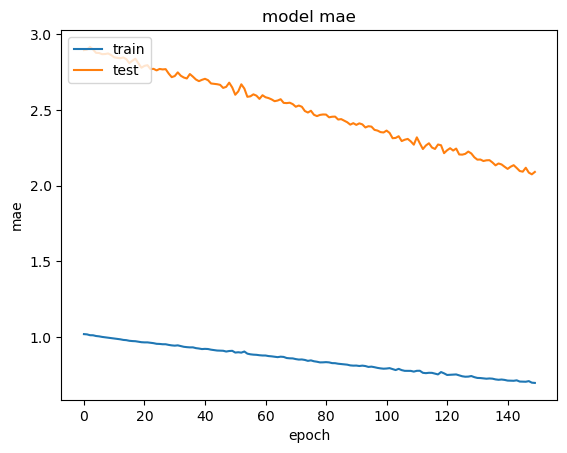

In [32]:
plt.plot(history.history["mae"])
plt.plot(history.history["val_mae"])
plt.title("model mae")
plt.ylabel("mae")
plt.xlabel("epoch")
plt.legend(["train","test"],loc = "upper left")
plt.show()

In [33]:
model2 = Sequential()
model2.add(Dense(12, input_dim=30, activation='relu'))
model2.add(Dense(8, activation='relu'))
model2.add(Dense(1, activation='sigmoid'))
model2.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
history = model2.fit(x, y, epochs=15,validation_split=0.33, batch_size=10)
scores = model2.evaluate(x, y)
print("%s: %.2f%%" % (model2.metrics_names[1], scores[1]*100))

Epoch 1/15
35/35 [==============================] - 1s 8ms/step - loss: 71.9590 - accuracy: 0.2405 - val_loss: 16.8710 - val_accuracy: 0.3631
Epoch 2/15
35/35 [==============================] - 0s 3ms/step - loss: 6.1731 - accuracy: 0.6628 - val_loss: 4.7220 - val_accuracy: 0.6786
Epoch 3/15
35/35 [==============================] - 0s 3ms/step - loss: 1.8914 - accuracy: 0.6833 - val_loss: 2.8596 - val_accuracy: 0.6845
Epoch 4/15
35/35 [==============================] - 0s 3ms/step - loss: 1.1866 - accuracy: 0.7126 - val_loss: 2.4848 - val_accuracy: 0.6964
Epoch 5/15
35/35 [==============================] - 0s 4ms/step - loss: 0.9206 - accuracy: 0.7595 - val_loss: 1.9829 - val_accuracy: 0.7202
Epoch 6/15
35/35 [==============================] - 0s 4ms/step - loss: 0.7118 - accuracy: 0.7859 - val_loss: 1.4562 - val_accuracy: 0.7560
Epoch 7/15
35/35 [==============================] - 0s 3ms/step - loss: 0.5474 - accuracy: 0.8035 - val_loss: 0.9558 - val_accuracy: 0.7500
Epoch 8/15
35/35 [

In [34]:
model3= Sequential()
model3.add(Dense(12, input_dim=30, activation='tanh'))
model3.add(Dense(8, activation='tanh'))
model3.add(Dense(1, activation='relu'))
model3.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
history = model3.fit(x, y, epochs=15,validation_split=0.33, batch_size=10)
scores = model3.evaluate(x, y)
print("%s: %.2f%%" % (model3.metrics_names[1], scores[1]*100))

Epoch 1/15
35/35 [==============================] - 1s 8ms/step - loss: 9.2759 - accuracy: 0.3578 - val_loss: 7.7836 - val_accuracy: 0.3988
Epoch 2/15
35/35 [==============================] - 0s 4ms/step - loss: 3.6975 - accuracy: 0.3783 - val_loss: 4.5152 - val_accuracy: 0.4107
Epoch 3/15
35/35 [==============================] - 0s 4ms/step - loss: 2.1461 - accuracy: 0.3783 - val_loss: 2.5955 - val_accuracy: 0.4107
Epoch 4/15
35/35 [==============================] - 0s 4ms/step - loss: 1.3060 - accuracy: 0.4370 - val_loss: 3.2334 - val_accuracy: 0.6131
Epoch 5/15
35/35 [==============================] - 0s 3ms/step - loss: 0.9385 - accuracy: 0.7478 - val_loss: 2.6232 - val_accuracy: 0.6131
Epoch 6/15
35/35 [==============================] - 0s 3ms/step - loss: 0.8189 - accuracy: 0.7566 - val_loss: 2.5006 - val_accuracy: 0.6131
Epoch 7/15
35/35 [==============================] - 0s 5ms/step - loss: 0.8065 - accuracy: 0.7537 - val_loss: 3.6966 - val_accuracy: 0.5774
Epoch 8/15
35/35 [==

In [36]:
from sklearn.preprocessing import StandardScaler
standard_scaler=StandardScaler()
column_names=df1.columns
data=pd.DataFrame(standard_scaler.fit_transform(df1),columns=column_names)
data

,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,...,monthfeb,monthjan,monthjul,monthjun,monthmar,monthmay,monthnov,monthoct,monthsep,size_category
0,0.271858,-1.424495,-0.796040,-1.318386,-1.828931,-0.856568,-1.827729,0.412656,1.494370,-0.069035,...,-0.202237,-0.062807,-0.25901,-0.180151,2.933219,-0.062807,-0.044368,-0.174254,-0.714413,0.609892
1,0.958019,1.178046,-0.003257,-1.174053,0.489257,-0.507267,-0.148307,-0.688321,-1.729364,-0.069035,...,-0.202237,-0.062807,-0.25901,-0.180151,-0.340922,-0.062807,-0.044368,5.738757,-0.714413,0.609892
2,0.958019,-0.383478,-0.003257,-1.043839,0.561045,-0.507267,-0.730964,-0.688321,-1.507037,-0.069035,...,-0.202237,-0.062807,-0.25901,-0.180151,-0.340922,-0.062807,-0.044368,5.738757,-0.714413,0.609892
3,0.271858,-1.424495,0.194939,-1.206998,-1.896686,-0.005147,-1.810592,3.226265,-0.006333,0.606709,...,-0.202237,-0.062807,-0.25901,-0.180151,2.933219,-0.062807,-0.044368,-0.174254,-0.714413,0.609892
4,0.271858,0.137030,-0.237488,-0.924607,-1.797070,0.125841,-1.279346,3.348596,-1.229129,-0.069035,...,-0.202237,-0.062807,-0.25901,-0.180151,2.933219,-0.062807,-0.044368,-0.174254,-0.714413,0.609892
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
504,-1.100464,0.137030,-1.624859,-0.839890,0.475141,-1.555170,1.531115,-0.749487,-0.728894,-0.069035,...,-0.202237,-0.062807,-0.25901,-0.180151,-0.340922,-0.062807,-0.044368,-0.174254,-0.714413,-1.639636
505,-1.100464,0.137030,-1.624859,-0.839890,0.475141,-1.555170,0.520034,1.635965,0.994136,-0.069035,...,-0.202237,-0.062807,-0.25901,-0.180151,-0.340922,-0.062807,-0.044368,-0.174254,-0.714413,-1.639636
506,-1.100464,0.137030,-1.624859,-0.839890,0.475141,-1.555170,0.400076,1.574799,1.494370,-0.069035,...,-0.202237,-0.062807,-0.25901,-0.180151,-0.340922,-0.062807,-0.044368,-0.174254,-0.714413,-1.639636
507,-1.100464,-0.383478,0.681420,0.561083,0.269860,0.496973,1.154102,-0.137832,-0.006333,-0.069035,...,-0.202237,-0.062807,-0.25901,-0.180151,-0.340922,-0.062807,-0.044368,-0.174254,-0.714413,0.609892


In [39]:
X=df1.drop(columns='size_category')
Y=df1[["size_category"]]

In [40]:
model4 = Sequential()
model4.add(Dense(12, input_dim=30, activation='relu'))
model4.add(Dense(8, activation='relu'))
model4.add(Dense(1, activation='sigmoid'))
model4.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
history = model4.fit(X, Y, epochs=15,validation_split=0.33, batch_size=10)
scores = model4.evaluate(X, Y)
print("%s: %.2f%%" % (model4.metrics_names[1], scores[1]*100))

Epoch 1/15
35/35 [==============================] - 1s 7ms/step - loss: 71.2241 - accuracy: 0.2405 - val_loss: 42.3528 - val_accuracy: 0.3155
Epoch 2/15
35/35 [==============================] - 0s 3ms/step - loss: 17.4154 - accuracy: 0.4047 - val_loss: 3.1178 - val_accuracy: 0.6488
Epoch 3/15
35/35 [==============================] - 0s 3ms/step - loss: 1.5046 - accuracy: 0.7185 - val_loss: 1.2633 - val_accuracy: 0.5774
Epoch 4/15
35/35 [==============================] - 0s 3ms/step - loss: 0.8607 - accuracy: 0.6891 - val_loss: 1.0796 - val_accuracy: 0.6429
Epoch 5/15
35/35 [==============================] - 0s 3ms/step - loss: 0.7002 - accuracy: 0.7361 - val_loss: 0.7827 - val_accuracy: 0.6310
Epoch 6/15
35/35 [==============================] - 0s 3ms/step - loss: 0.5804 - accuracy: 0.7801 - val_loss: 0.6693 - val_accuracy: 0.6726
Epoch 7/15
35/35 [==============================] - 0s 3ms/step - loss: 0.5219 - accuracy: 0.7713 - val_loss: 0.7458 - val_accuracy: 0.7024
Epoch 8/15
35/35 

In [45]:
def baseline_model():
    model = Sequential()
    model.add(Dense(10, input_dim=30, activation='tanh'))
    model.add(Dense(1))
    model.compile(loss='mean_squared_error', optimizer='adam')
    return model

In [46]:
import keras
from sklearn.model_selection import KFold
from keras.wrappers.scikit_learn import KerasRegressor
from keras.models import Sequential
from keras.layers import InputLayer,Dense
from sklearn.model_selection import cross_val_score
estimator = KerasRegressor(build_fn=baseline_model, nb_epoch=50, batch_size=100, verbose=False)
kfold = KFold(n_splits=10)
results = cross_val_score(estimator, X, Y, cv=kfold)
print("Results: %.2f (%.2f) MSE" % (results.mean(), results.std()))

Results: -1.24 (1.10) MSE


In [47]:
estimator.fit(x, y)
prediction = estimator.predict(X)
prediction

array([ 0.40535396,  0.11460508,  0.11460508, -0.39310858, -0.39307448,
        0.11460508,  0.11460508,  0.11460508,  0.11460508,  0.11460508,
        0.11460508,  0.11460508,  0.11460508,  0.11460508,  0.11460508,
        0.11460508,  1.2006847 ,  0.11460508,  1.1948729 ,  0.57200384,
        0.11460508,  0.11460508,  0.29450074,  0.11460508,  0.11460508,
        0.11460508,  0.11460508,  0.11460508,  0.11460508,  0.11460508,
        0.11460508,  0.11460508,  0.11460508,  0.11460508,  0.11460508,
        0.11460508,  0.11460508,  0.11460508,  0.11460508,  0.6200804 ,
        0.11460508,  0.11460508,  0.11460508,  0.11460508,  0.11460508,
        0.11460508,  0.11460508,  0.11460508,  1.1533458 ,  1.2229695 ,
        0.11460508,  0.11460508,  0.11460508,  0.11460508,  0.11460508,
        0.11460508,  0.11460508,  0.14915697,  0.3422912 ,  1.1891985 ,
        0.59188634,  0.11460508,  0.11460508,  0.11460508,  0.11460508,
        0.11460508,  0.11460508,  0.11460508,  1.1965858 ,  0.57

In [48]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3)

In [51]:
estimator.fit(x_train, y_train)
prediction = estimator.predict(x_test)

In [52]:
prediction

array([ 0.9541198 ,  0.9541198 ,  0.9541198 ,  0.954119  ,  0.9541198 ,
        0.9541198 ,  0.9541198 ,  0.93604404, -0.18595642, -0.18764132,
        0.9541198 , -0.18764168, -0.18764168,  0.9541198 ,  0.747579  ,
        0.9541198 ,  0.9541198 ,  0.24366552,  0.9541198 ,  0.9541198 ,
        0.9541198 , -0.18764168,  0.9541198 ,  0.9541198 ,  0.9541198 ,
        0.95411533,  0.9541198 ,  0.9541198 ,  0.9541197 ,  0.9541198 ,
        0.9541198 ,  0.9541198 ,  0.9541198 ,  0.95411813,  0.9541198 ,
        0.954116  ,  0.9541163 ,  0.9541198 , -0.1876362 ,  0.9541198 ,
        0.9541198 ,  0.9541198 ,  0.238024  ,  0.9541198 ,  0.9541156 ,
        0.9541198 ,  0.9541198 ,  0.9516271 ,  0.94728273, -0.18764168,
        0.9541198 , -0.18764168,  0.9541198 , -0.18684268,  0.9536393 ,
       -0.18764168,  0.9541198 ,  0.9541198 , -0.18724215, -0.17843801,
        0.9541198 ,  0.9541198 , -0.18764168,  0.9541198 ,  0.9541198 ,
        0.9541198 , -0.17897397,  0.76370764,  0.9541173 ,  0.95